In [26]:
from pathlib import Path
from pyexpat import features

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from contourpy.util.mpl_util import lines_to_mpl_paths
from pandas import read_json
from prompt_toolkit.key_binding.bindings.mouse import load_mouse_bindings

from mastercard import dist_visualisation, dist_categorical_visualisation



In [2]:
PROCESSED_DATA = Path("../data/processed")

In [3]:
# RAW_DATA

In [4]:
df = pd.read_parquet(PROCESSED_DATA / 'transactions.parquet')

In [5]:
df.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,1,145,0,0
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,1,32,1,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,1,604,1,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,0,1031,1,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,1,330,0,0


In [6]:
print('Initial shape', df.shape)

Initial shape (500000, 14)


In [7]:
# List features
df.columns

Index(['transaction_id', 'timestamp', 'user_id', 'merchant_id', 'amount',
       'channel', 'currency', 'device', 'location', 'payment_method',
       'is_international', 'session_length_seconds', 'is_first_time_merchant',
       'is_fraud'],
      dtype='object')

In [8]:
df.dtypes

transaction_id                    object
timestamp                 datetime64[ns]
user_id                           object
merchant_id                       object
amount                           float64
channel                           object
currency                          object
device                            object
location                          object
payment_method                    object
is_international                   int64
session_length_seconds             int64
is_first_time_merchant             int64
is_fraud                           int64
dtype: object

In [9]:
df.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,1,145,0,0
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,1,32,1,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,1,604,1,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,0,1031,1,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,1,330,0,0


In [10]:
df.sample(n=10)

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
109488,TX109488,2023-11-13 12:41:00,U00345,M0263,23.61,in-store,EUR,Web,"{'lat': 61.270732, 'long': 21.085531}",credit_card,1,920,1,0
167597,TX167597,2022-07-03 15:24:00,U13747,M0204,31.27,online,EUR,iOS,"{'lat': 44.419437, 'long': 2.49614}",bank_transfer,1,1110,0,0
220502,TX220502,2023-09-24 17:48:00,U14397,M0359,52.35,in-store,EUR,Android,"{'lat': 63.982408, 'long': -9.93988}",debit_card,1,270,0,0
136720,TX136720,2022-03-01 06:20:00,U10348,M0845,46.97,online,EUR,iOS,"{'lat': 64.471077, 'long': -8.950107}",debit_card,1,958,1,0
376221,TX376221,2022-11-25 04:16:00,U00946,M0160,0.70,online,EUR,iOS,"{'lat': 67.164513, 'long': -7.1620989999999995}",credit_card,0,216,0,0
207051,TX207051,2022-08-31 06:47:00,U17574,M0446,6.47,mobile,EUR,iOS,"{'lat': 50.747299, 'long': 1.496624}",credit_card,1,1175,1,0
299059,TX299059,2022-10-28 11:11:00,U14725,M0659,15.47,in-store,EUR,Web,"{'lat': 43.900605, 'long': 7.38488}",debit_card,1,1000,1,0
438478,TX438478,2023-06-25 03:23:00,U09229,M0216,45.86,online,EUR,Android,"{'lat': 52.144933, 'long': 34.299662}",bank_transfer,1,415,1,0
463767,TX463767,2023-02-25 11:36:00,U17787,M0537,209.03,in-store,EUR,iOS,"{'lat': 48.102546, 'long': 0.043146}",bank_transfer,1,672,1,0
374664,TX374664,2023-03-08 16:29:00,U07758,M0705,24.68,in-store,EUR,Web,"{'lat': 57.232087, 'long': 29.378495}",credit_card,1,611,0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   transaction_id          500000 non-null  object        
 1   timestamp               500000 non-null  datetime64[ns]
 2   user_id                 500000 non-null  object        
 3   merchant_id             500000 non-null  object        
 4   amount                  500000 non-null  float64       
 5   channel                 500000 non-null  object        
 6   currency                500000 non-null  object        
 7   device                  500000 non-null  object        
 8   location                500000 non-null  object        
 9   payment_method          500000 non-null  object        
 10  is_international        500000 non-null  int64         
 11  session_length_seconds  500000 non-null  int64         
 12  is_first_time_merchant  500000

## Descriptive statistics

- univariate analysis
- bivariate analysis
- multivariate analysis

In [12]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,500000,2022-12-31 16:45:04.497720576,2022-01-01 00:06:00,2022-07-01 11:03:45,2022-12-31 20:08:30,2023-07-02 08:45:15,2023-12-31 23:57:00,NaN
amount,500000.0,49.915662,0.0,14.37,34.56,69.1725,714.86,49.990657
is_international,500000.0,0.928662,0.0,1.0,1.0,1.0,1.0,0.257389
session_length_seconds,500000.0,614.987182,30.0,323.0,614.0,907.0,1200.0,338.091496
is_first_time_merchant,500000.0,0.501248,0.0,0.0,1.0,1.0,1.0,0.499999
is_fraud,500000.0,0.084822,0.0,0.0,0.0,0.0,1.0,0.278617


### Target variable

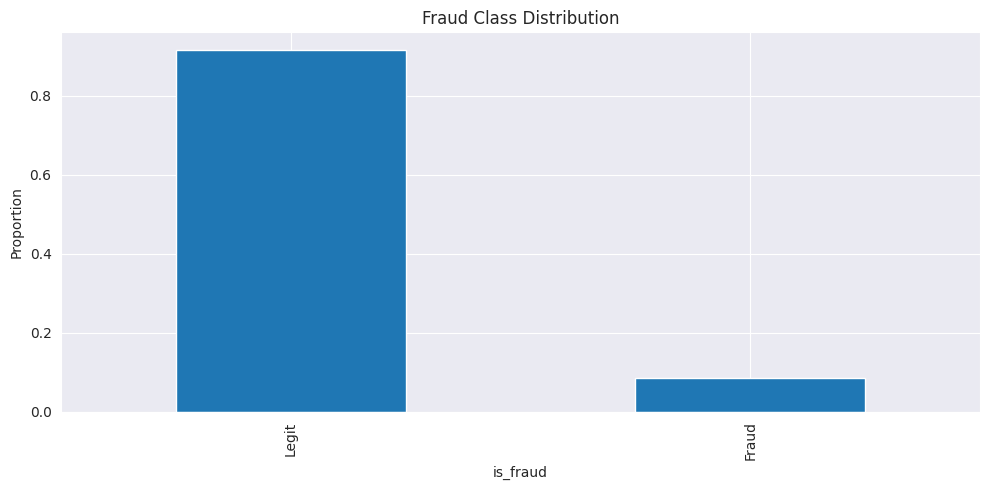

In [13]:
fraud_counts = df['is_fraud'].value_counts(normalize=True)

fix, ax = plt.subplots(figsize=(10, 5))

fraud_counts.plot(kind='bar', ax=ax)
ax.set_title('Fraud Class Distribution')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legit', 'Fraud'])
ax.set_ylabel('Proportion')

plt.tight_layout()
plt.show()

##### Summary: Class distribution is highly imbalanced

- accuracy - will be misleading
- use metrics like F1-score, Recall, ROC-AUC
- consider resampling (undersample, oversample)
- use algorithms with bulit-in the support imbalanced data (e.g. XGBoost)

### Numerical features

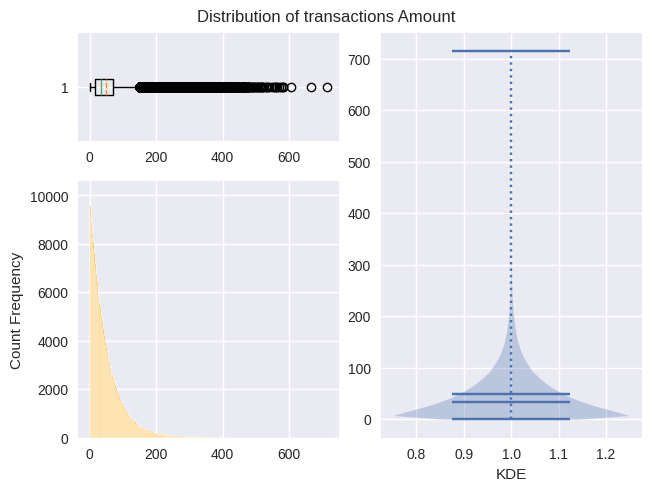

In [14]:
dist_visualisation(df['amount'], title='Distribution of transactions Amount')

In [15]:
df.loc[df['amount'] < 1, 'amount'].count()

np.int64(9986)

In [16]:
df.loc[df['amount'] == 0, 'amount'].count()

np.int64(43)

In [17]:
df['amount'].describe()

count    500000.000000
mean         49.915662
std          49.990657
min           0.000000
25%          14.370000
50%          34.560000
75%          69.172500
max         714.860000
Name: amount, dtype: float64

#### Summary: amount is strongly right-skewed with a long tail, this suggest the presence of outliers

- recommendation: apply log transformation (e.g.log1p) for algorithms sensitive to distribution shape

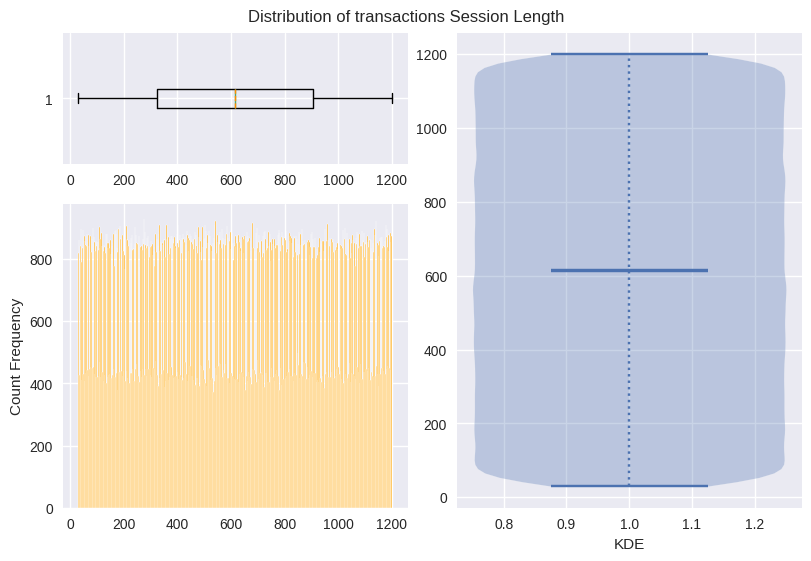

In [18]:
dist_visualisation(df['session_length_seconds'], title='Distribution of transactions Session Length')

#### Summary: session_length_seconds is uniform distributed, which is unusual in real behavioral data

- indicates synthetic generation or flattening
- low predictive power unless frauds are focused in specific ranges (to be checked later)

## Categorical features

In [19]:
df.dtypes

transaction_id                    object
timestamp                 datetime64[ns]
user_id                           object
merchant_id                       object
amount                           float64
channel                           object
currency                          object
device                            object
location                          object
payment_method                    object
is_international                   int64
session_length_seconds             int64
is_first_time_merchant             int64
is_fraud                           int64
dtype: object

In [20]:
df.columns

Index(['transaction_id', 'timestamp', 'user_id', 'merchant_id', 'amount',
       'channel', 'currency', 'device', 'location', 'payment_method',
       'is_international', 'session_length_seconds', 'is_first_time_merchant',
       'is_fraud'],
      dtype='object')

In [21]:
categorical_cols = ['channel', 'currency', 'device', 'payment_method', 'is_international', 'is_first_time_merchant' ]

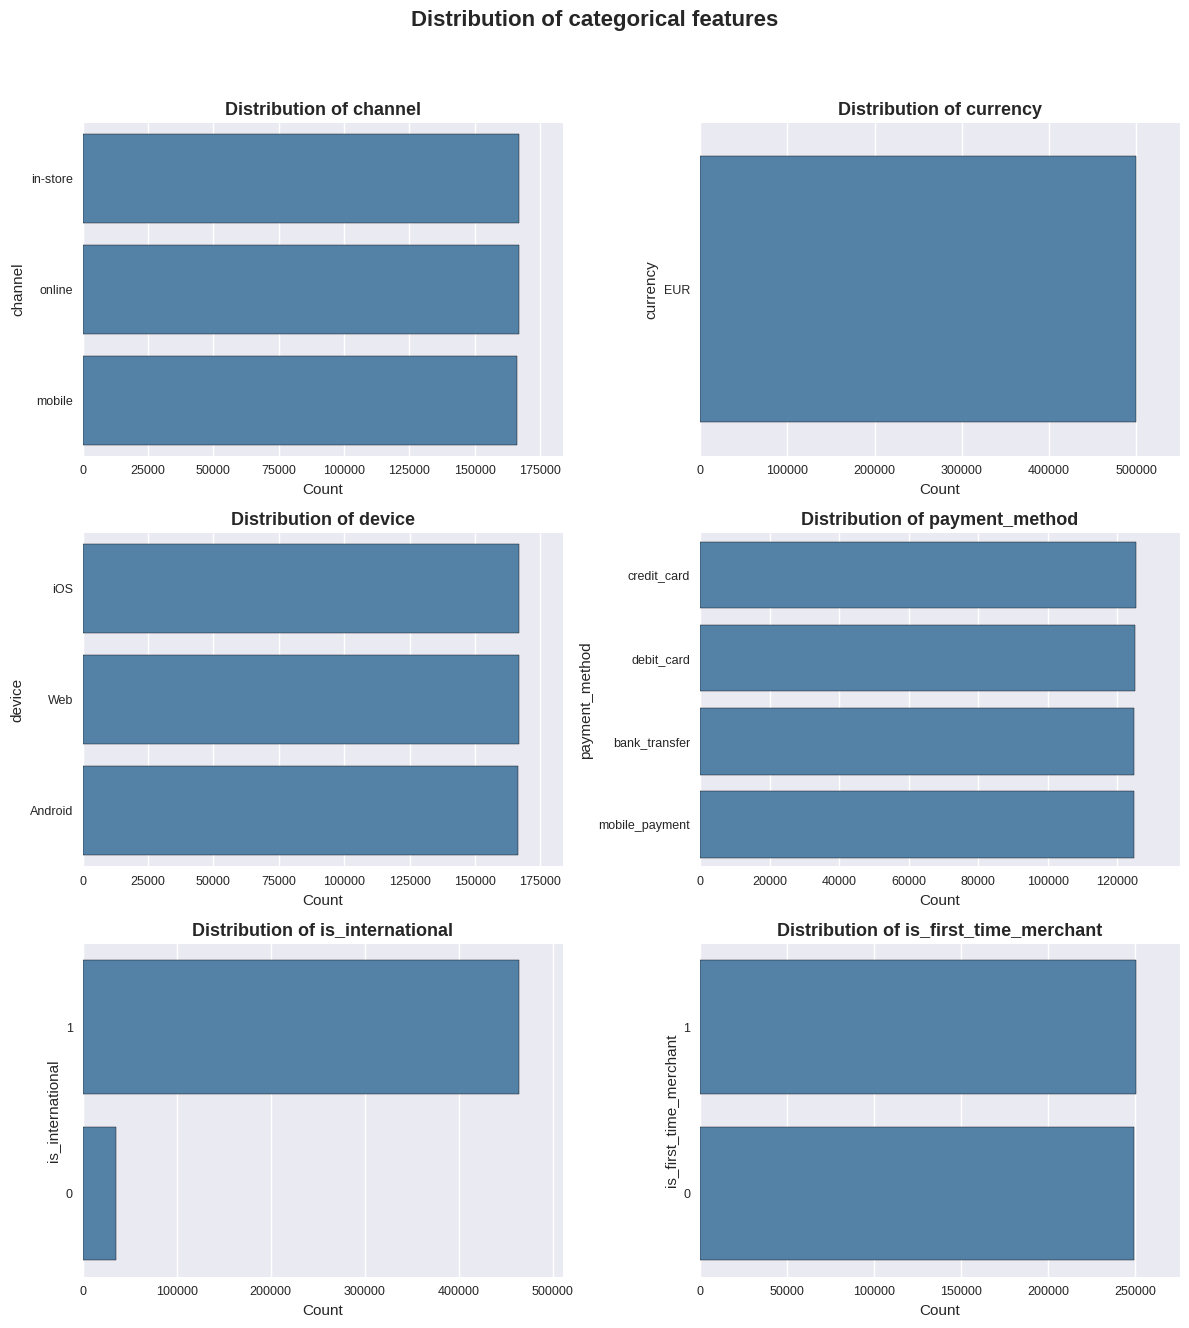

In [22]:
fig, ax = dist_categorical_visualisation(df, categorical_cols, title='Distribution of categorical features')

In [23]:
df['channel'].value_counts()

channel
in-store    167027
online      166847
mobile      166126
Name: count, dtype: int64

#### Summary:
- channel, device, payment_method show almost perfectly balanced category distribution
    - unusual in real-word data and indicates synthetic balancing or controlled generation
- currency has only one value, making it non-informative
    - recommended : drop this feature

## Multivariate analysis

#### Amount vs is_fraud

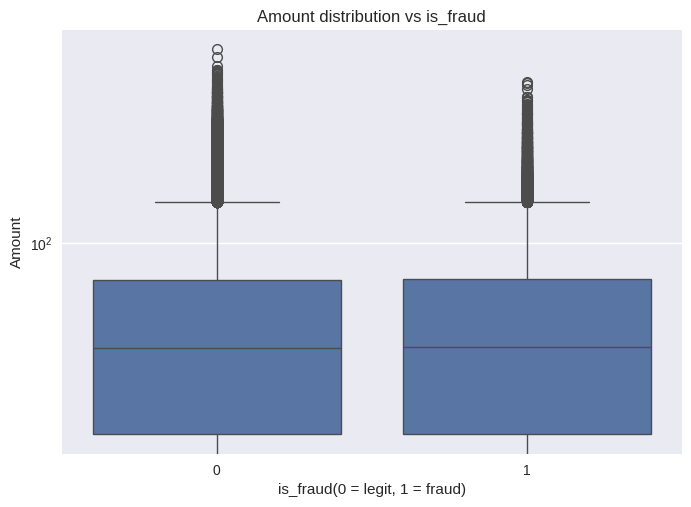

In [24]:
fig, ax = plt.subplots()

sns.boxplot(x='is_fraud', y='amount', data=df, ax=ax)
ax.set_title('Amount distribution vs is_fraud')
ax.set_xlabel('is_fraud(0 = legit, 1 = fraud)')
ax.set_ylabel('Amount')
ax.set_yscale('log')

#### Summary:
- amount is not a discriminative feature by itself for froud detection
- distribution are very similar
- may still be useful when combined with other features

#### Session Length Seconds vs is_fraud

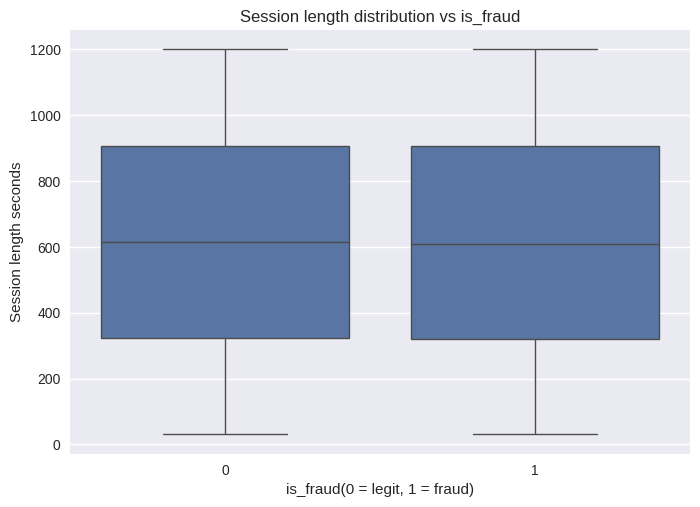

In [25]:
fig, ax = plt.subplots()

sns.boxplot(x='is_fraud', y='session_length_seconds', data=df, ax=ax)
ax.set_title('Session length distribution vs is_fraud')
ax.set_xlabel('is_fraud(0 = legit, 1 = fraud)')
ax.set_ylabel('Session length seconds')
# ax.set_yscale('log')

plt.show()

## Time-based analysis

In [27]:
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek

In [28]:
df.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud,hour,dayofweek
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,1,145,0,0,23,4
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,1,32,1,0,15,1
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,1,604,1,0,21,4
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,0,1031,1,0,6,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,1,330,0,0,8,3


In [29]:
df_ts = df.set_index('timestamp').sort_index()
fraud_counts = df_ts.resample('W')['is_fraud'].sum()
total_counts = df_ts.resample('W')['is_fraud'].count()
fraud_rate = (fraud_counts / total_counts).fillna(0)

In [30]:
fraud_rate

timestamp
2022-01-02    0.080942
2022-01-09    0.081751
2022-01-16    0.092311
2022-01-23    0.087424
2022-01-30    0.087745
                ...   
2023-12-03    0.085848
2023-12-10    0.085172
2023-12-17    0.086800
2023-12-24    0.081901
2023-12-31    0.091213
Freq: W-SUN, Name: is_fraud, Length: 105, dtype: float64

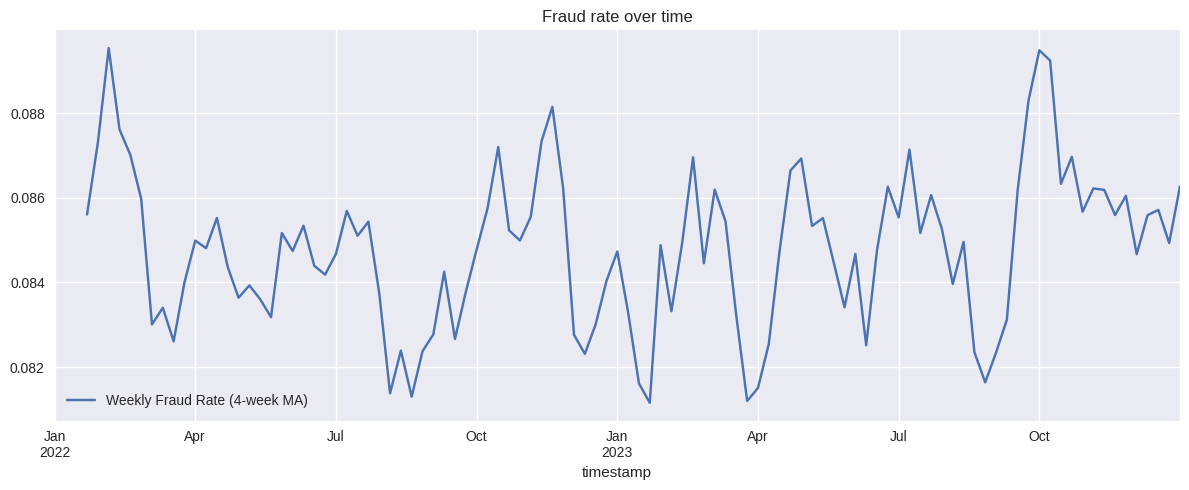

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

fraud_rate.rolling(4).mean().plot(ax=ax, label='Weekly Fraud Rate (4-week MA)')

ax.set_label('Fraud rate')
ax.set_title('Fraud rate over time')
# ax.set_ylim(0, 1)
ax.legend()

fig.tight_layout()
plt.show()

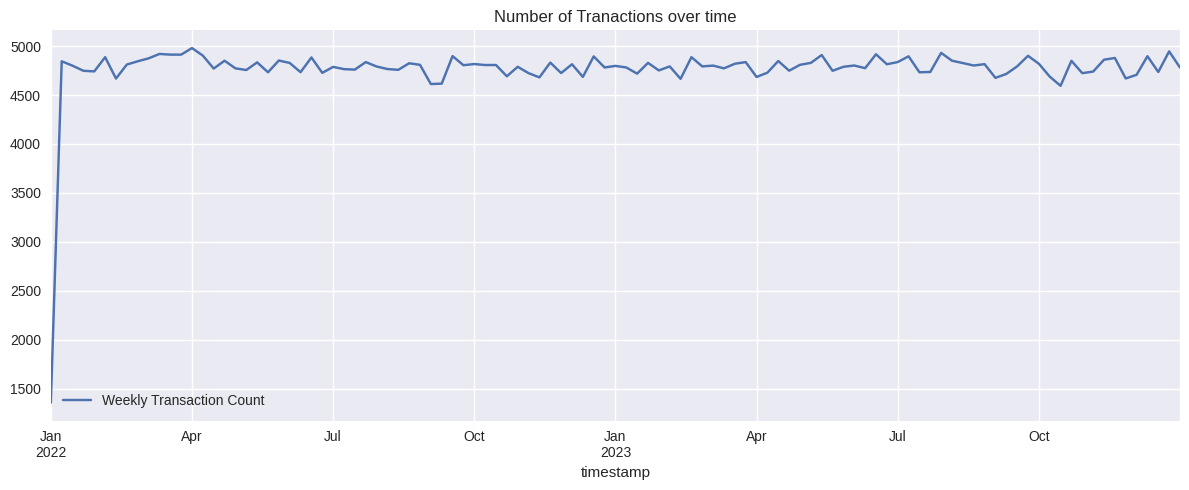

In [35]:
fig, ax = plt.subplots(figsize=(12, 5))

total_counts.plot(ax=ax, label='Weekly Transaction Count')

ax.set_label('Transaction Count')
ax.set_title('Number of Transactions over time')
# ax.set_ylim(0, 1)
ax.legend()

fig.tight_layout()
plt.show()

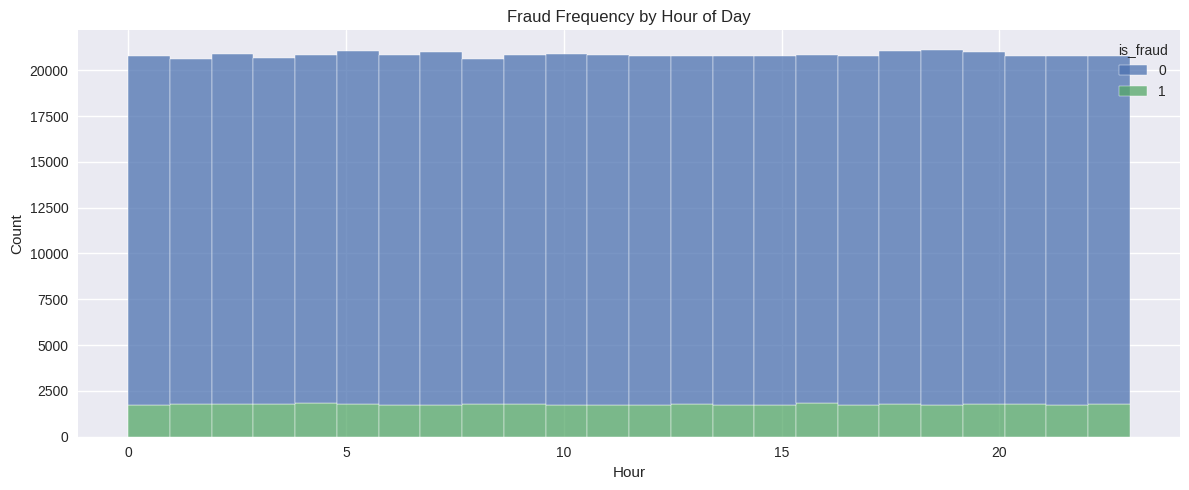

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(data=df_ts, x='hour', hue='is_fraud', bins=24, ax=ax, multiple='stack')

ax.set_xlabel("Hour")
ax.set_ylabel("Count")
ax.set_title("Fraud Frequency by Hour of Day")


fig.tight_layout()
plt.show()

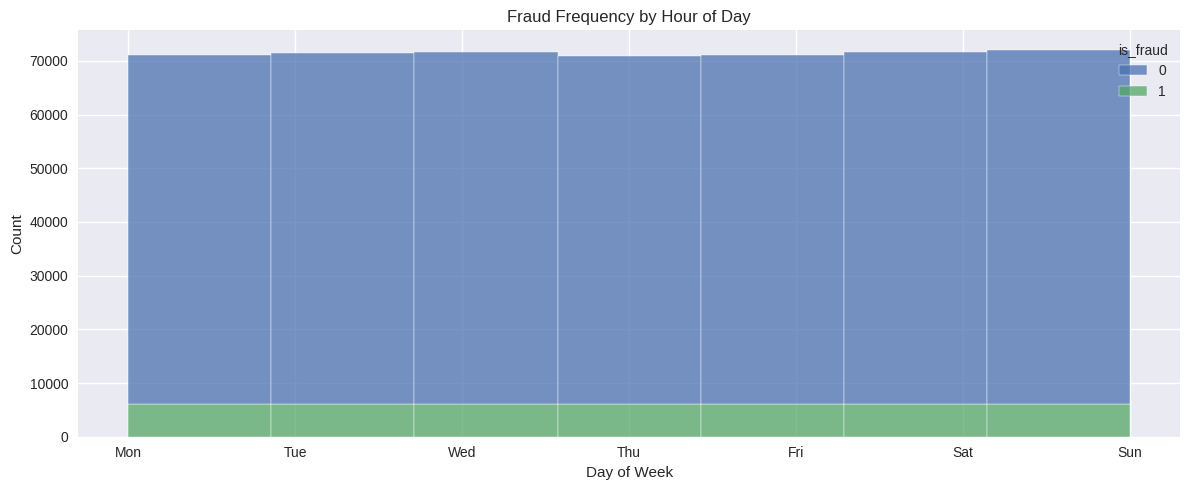

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(data=df_ts, x='dayofweek', hue='is_fraud', bins=7, ax=ax, multiple='stack')

ax.set_xlabel("Day of Week")
ax.set_xticks(range(7))
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax.set_ylabel("Count")
ax.set_title("Fraud Frequency by Hour of Day")


fig.tight_layout()
plt.show()

#### 1. Fraud Rate Over Time (weekly trend)
- The fraud rate fluctuates mildly between ~8.1% and 8.9% over the two-year span.
- No clear upward or downward trend, but some short-term volatility is present.
- Suggests that fraud behavior is stationary over time (non-seasonal).

#### 2. Fraud Frequency by Hour of Day
- Fraud and legit transactions are evenly distributed across all hours.
- No visible peak during night or business hours.
- Indicates time of day likely has no predictive signal.

#### 3. Average Fraud Rate by Day of Week
- All days show nearly equal fraud rates (~8.5%).
- No significant weekday vs. weekend pattern.

### Summary
- Time-based features appear non-informative in isolation.
- Their value may emerge only through interactions or in tree-based models.
- Results align with the synthetic structure of the dataset.

### Correlation matrix

In [39]:
features = ['amount', 'session_length_seconds', 'is_fraud']
corr = df_ts[features].corr()

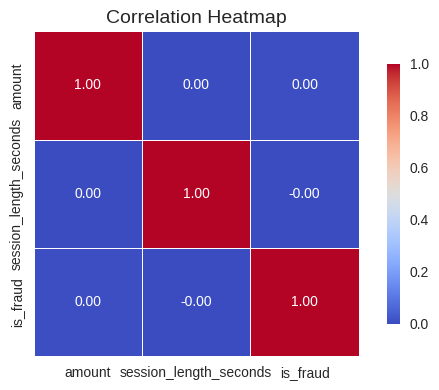

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=.5,
    cbar_kws={'shrink': 0.8},
    cmap='coolwarm'
)

ax.set_title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## Implication
- simple linear models (like logistic Regression) on raw features will perform poorly.
- more advanced models will be required. (e.g. decision tress, boosting, neural nets)